In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# === 1. Baca dataset ===
df = pd.read_csv("processed_kelulusan.csv")
print("Data asli:", df.shape)

# === 2. Gandakan dataset supaya cukup besar ===
df_big = pd.concat([df]*5, ignore_index=True)
print("Data setelah digandakan:", df_big.shape)

# === 3. Pisahkan fitur dan target ===
X = df_big.drop("Lulus", axis=1)
y = df_big["Lulus"]

# === 4. Normalisasi fitur (penting untuk ANN nanti) ===
sc = StandardScaler()
Xs = sc.fit_transform(X)

# === 5. Split Train (70%) dan Temp (30%) dengan stratify ===
X_train, X_temp, y_train, y_temp = train_test_split(
    Xs, y, test_size=0.3, stratify=y, random_state=42
)

# === 6. Split Temp jadi Validation (15%) dan Test (15%) ===
# Karena data sudah cukup banyak, stratify boleh dipakai lagi
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# === 7. Cek hasil ===
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("\nDistribusi label:")
print("Train:", y_train.value_counts().to_dict())
print("Val  :", y_val.value_counts().to_dict())
print("Test :", y_test.value_counts().to_dict())

Data asli: (10, 6)
Data setelah digandakan: (50, 6)
Train: (35, 5)
Validation: (7, 5)
Test: (8, 5)

Distribusi label:
Train: {1: 18, 0: 17}
Val  : {0: 4, 1: 3}
Test : {1: 4, 0: 4}


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")  # klasifikasi biner
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy","AUC"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)            │ (None, 32)        │        192 │
├──────────────────────────┼───────────────────┼────────────┤
│ dropout (Dropout)        │ (None, 32)        │          0 │
├──────────────────────────┼───────────────────┼────────────┤
│ dense_1 (Dense)          │ (None, 16)        │        528 │
├──────────────────────────┼───────────────────┼────────────┤
│ dense_2 (Dense)          │ (None, 1)         │         17 │
└──────────────────────────┴───────────────────┴────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=32,
    callbacks=[es], verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 961ms/step - AUC: 0.5588 - accuracy: 0.4286 - loss: 0.7280 - val_AUC: 0.9167 - val_accuracy: 0.5714 - val_loss: 0.5911
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - AUC: 0.5065 - accuracy: 0.4571 - loss: 0.7282 - val_AUC: 1.0000 - val_accuracy: 0.5714 - val_loss: 0.5726
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - AUC: 0.6029 - accuracy: 0.4857 - loss: 0.6930 - val_AUC: 1.0000 - val_accuracy: 0.5714 - val_loss: 0.5543
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - AUC: 0.9346 - accuracy: 0.4857 - loss: 0.6106 - val_AUC: 1.0000 - val_accuracy: 0.5714 - val_loss: 0.5374
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - AUC: 0.8317 - accuracy: 0.4857 - loss: 0.6182 - val_AUC: 1.0000 - val_accuracy: 0.8571 - val_loss: 0.5216
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - AUC: 0.8676 - accuracy: 0.4857 - loss: 0.6061 - val_AUC: 1.0000 - val_accuracy: 0.8571 - val_loss: 0.5070
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

loss, acc, auc = model.evaluate(X_test, y_test, verbose=0)
print("Test Acc:", acc, "AUC:", auc)

y_proba = model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Test Acc: 1.0 AUC: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
[[4 0]
 [0 4]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         4
           1      1.000     1.000     1.000         4

    accuracy                          1.000         8
   macro avg      1.000     1.000     1.000         8
weighted avg      1.000     1.000     1.000         8



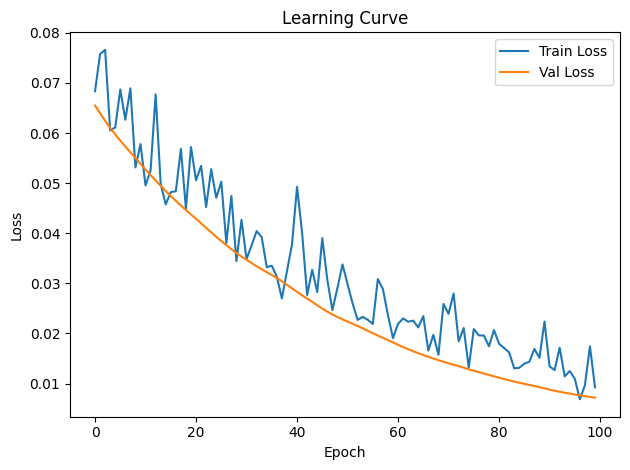

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Learning Curve")
plt.tight_layout(); plt.savefig("learning_curve.png", dpi=120)